In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1.

To implement RK-2, firstly I'll need to split the second order differential equation $y''(t)=-g$ into two coupled first order ones as such:
\begin{equation}
    \frac{dy}{dt} = v
\end{equation}
\begin{equation}
    \frac{dv}{dt} = -g
\end{equation}
Which I can then solve simultaneously by defing $\textbf{r} = (y(t), v(t))$.

40.0


Text(0, 0.5, 'y(t)')

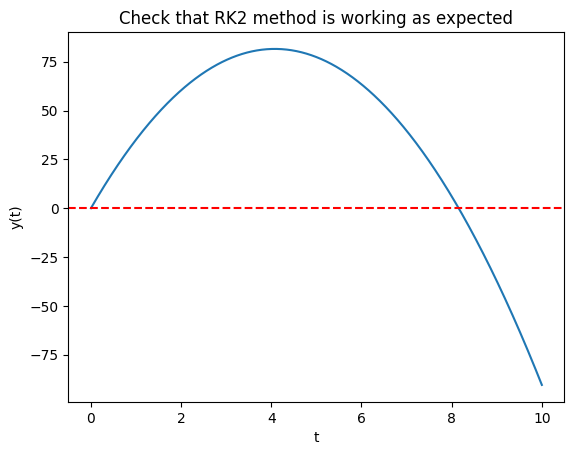

In [10]:
g = 9.81 # m/s^2

def f(r):
    y = r[0]
    v = r[1]

    fy = v
    fv = -g

    return np.array([fy,fv])

# implement RK-2
def RK2(v0):
    # discretize t grid from 0 to 10
    t_i = 0
    t_f = 10
    n = 1001
    h = (t_f-t_i)/(n-1)

    t = np.linspace(t_i,t_f,n)

    # create y and v arrays
    y = np.zeros(n)
    v = np.zeros(n)
    y[0] = 0
    v[0] = v0

    r = np.array([y[0],v[0]])

    for i in range(n-1):
        k1 = f(r)
        k2 = f(r+k1*h/2)

        r = r + h*k2

        y[i+1] = r[0]
        v[i+1] = r[1]

    return t, y, v

# check the RK2 is working as expected
t, y_check, v_check = RK2(40)

print(v_check[0])
plt.plot(t, y_check)
plt.axhline(y=0, ls='--', c='r')
plt.title('Check that RK2 method is working as expected')
plt.xlabel('t')
plt.ylabel('y(t)')

The RK2 function seems to be working fine since the resulting function seems to be parabolic. 

To implement the secant shooting method, I'll define $g(\alpha) = u_{\alpha}(x_{n-1}) - y(x_{n-1})$ where $\alpha$ is the shooting parameter, in this case the initial velocity, and $u_{\alpha}$ is the solution using $v(0) = \alpha$. Since $y(x_{n-1}) = 0$ for this problem, I just need to return $u_{\alpha}(x_{n-1})$.

49.050000000000225


Text(0, 0.5, 'y(t)')

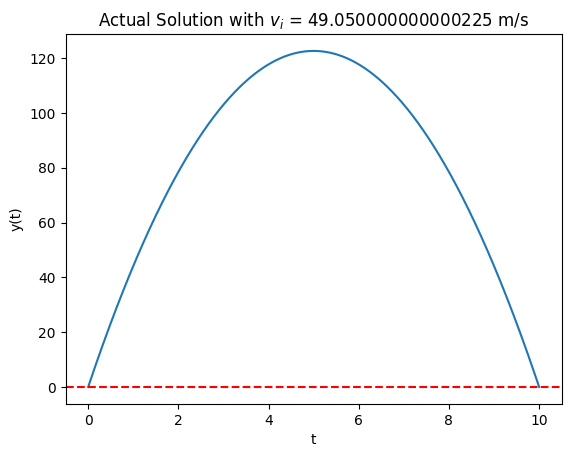

In [14]:
# define g function and return u(x_n-1)
def ga(alpha):
    t, y, v = RK2(alpha)
    return y[-1]

# implement secant method to solve for the shooting parameter
def Secant(v0, v1, tol=1e-8):
    for i in range(1,100):
        g0 = ga(v0)
        g1 = ga(v1)
    
        ratio = (v1 - v0) / (g1 - g0)
        v2 = v1 - g1*ratio

        if abs(v2-v1) < tol:
            break

        
        v0 = v1
        v1 = v2

    return v2

# compute the actual initial velocity
v_actual = Secant(40, 50)

t, y, v = RK2(v_actual)

print(v_actual)
plt.plot(t, y)
plt.axhline(y=0, ls='--', c='r')
plt.title(f'Actual Solution with $v_i$ = {v_actual} m/s')
plt.xlabel('t')
plt.ylabel('y(t)')